In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

ERROR! Session/line number was not unique in database. History logging moved to new session 379


Tasks
First, explore fitting this data with the tecniques we have seen.
Start from linear regression and polynomial regression
For the case of polynomial regression, just fit many of them for now.
Let's bet based on intuition! Which fit is the best?
In what cases are you underfitting the data?
In what cases are you overfitting the data?
Now split the data into training and validation sets
Implement a cross-validation procedure
Pick the best!
Does it agree with our bets?

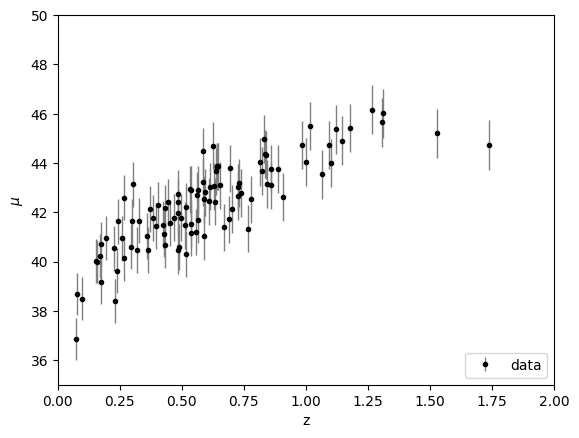

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


## Linear regression

In [3]:
# diagonal noise matrix
C = np.identity(len(z_sample)) * dmu**2

# design matrix
M = np.column_stack((np.ones(len(z_sample)), z_sample))

# Sigma^-1 = M^T * C^-1 * M
A = np.dot(np.dot(M.T, np.linalg.pinv(C)), M)

# M^T * C^-1 * y
B = np.dot(np.dot(M.T, np.linalg.pinv(C)), mu_sample)

# theta = Sigma * M^T * C^-1 * y
theta = np.dot(np.linalg.pinv(A),B)
print(theta)

[39.48384602  4.76438865]


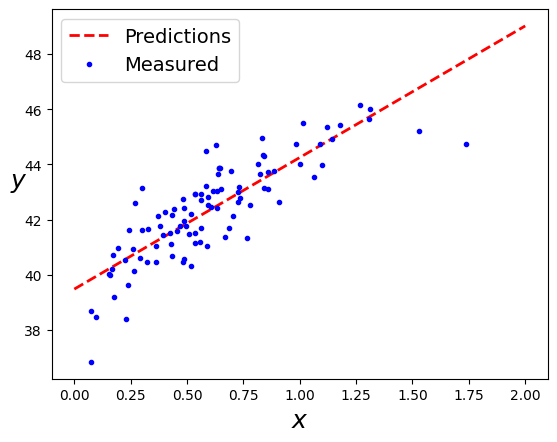

In [4]:
X_new = np.array([0,2]) #like X_grid, but just with the endpoints
y_pred = theta[0] + theta[1]*X_new  # Complete 

plt.plot(X_new, y_pred, "r--", linewidth=2, label="Predictions")
plt.plot(z_sample, mu_sample, "b.", label='Measured')
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression

z_reshape = np.sort(z_sample[:, np.newaxis])
lin_reg = LinearRegression()
lin_reg.fit(z_reshape, mu_sample, sample_weight=1/dmu**2)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
y_pred2 = lin_reg.predict(X_new[:,np.newaxis])

39.48384602295729 [4.76438865]


In [6]:
print(y_pred)
print(y_pred2)

[39.48384602 49.01262332]
[39.48384602 49.01262332]


## Polynomial regression

In [7]:
# Typical call
from astroML.linear_model import PolynomialRegression

degree = 3
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(z_reshape, mu_sample, dmu)

X_test = np.linspace(0,2, 10)
y_pred = model.predict(X_test[:,np.newaxis])
n_constraints = degree + 1

print(model.coef_)

[38.36452837  8.87820312 -3.06677777  0.17557977]


C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


[38.41076899  8.59831905 -2.64090751]
[38.36452837  8.87820312 -3.06677777  0.17557977]
[ 3.58116966e+01  1.62304591e+01  2.66880216e+02 -2.23100151e+03
  7.70078437e+03 -1.47441423e+04  1.71082188e+04 -1.23328772e+04
  5.41164139e+03 -1.32736125e+03  1.39977042e+02]


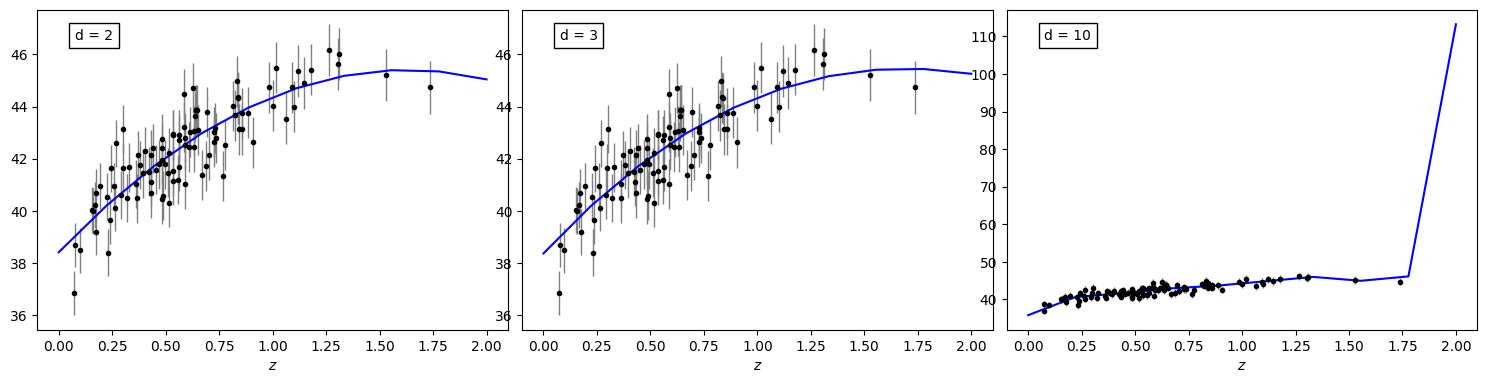

In [9]:
fig = plt.figure(figsize=(16, 4))
fig.subplots_adjust(wspace=0.03, bottom=0.15,
                    top=0.95, left=0.07, right=0.97)

for i, d in enumerate([2, 3,10]):  #Try 2nd, 3rd and 19th order
    ax = fig.add_subplot(131 + i)
    plt.errorbar(z_sample,  mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
    degree = d
    model = PolynomialRegression(degree) # fit 3rd degree polynomial
    model.fit(z_reshape, mu_sample, dmu)

    y_pred = model.predict(X_test[:,np.newaxis])
    n_constraints = degree + 1
    #print(y_pred[-1])
    print(model.coef_)
    #p = np.polyfit(z_sample,mu_sample, d)
    #y_fit = np.polyval(p, X_test)

    ax.plot(X_test, y_pred, '-b')
   # ax.set_ylim(-0.1, 2.1)
   # ax.set_xlim(-0.2, 3.2)
    #if i in (1, 2):
     #   ax.yaxis.set_major_formatter(plt.NullFormatter())
    #else:
     #   ax.set_ylabel('$y$')
    ax.set_xlabel('$z$')
    ax.text(0.08, 0.94, "d = %i" % d, transform=ax.transAxes,
            ha='left', va='top',
            bbox=dict(ec='k', fc='w'))

plt.show()

## Cross validation for d

### Polynomial regression

Text(0.5, 1.0, 'Validation curve')

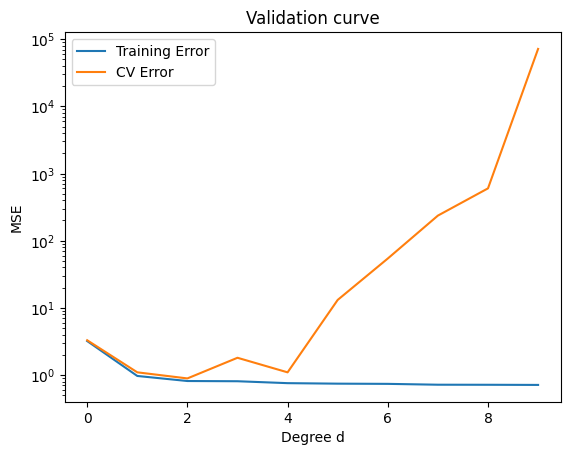

In [10]:
degrees = np.arange(0, 10)
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_errors = []
cv_errors = []

for d in degrees:
    t_err = []
    v_err = []
    
    
    
    
    for train_idx, val_idx in kf.split(z_reshape):
        # Split
        X_train, X_val = z_reshape[train_idx], z_reshape[val_idx]
        y_train, y_val = mu_sample[train_idx], mu_sample[val_idx]
        err_train, err_val = dmu[train_idx], dmu[val_idx]
        model = PolynomialRegression(d)
        model.fit(X_train, y_train, err_train )
        
        # Predict
        t_err.append(mean_squared_error(y_train, model.predict(X_train)))
        v_err.append(mean_squared_error(y_val, model.predict(X_val)))
        
    train_errors.append(np.mean(t_err))
    cv_errors.append(np.mean(v_err))

# Plot Validation Curve
plt.plot(degrees, (train_errors), label='Training Error')
plt.plot(degrees, cv_errors, label='CV Error')
plt.yscale('log')
plt.xlabel('Degree d')
plt.ylabel('MSE')
plt.legend()
plt.title("Validation curve")

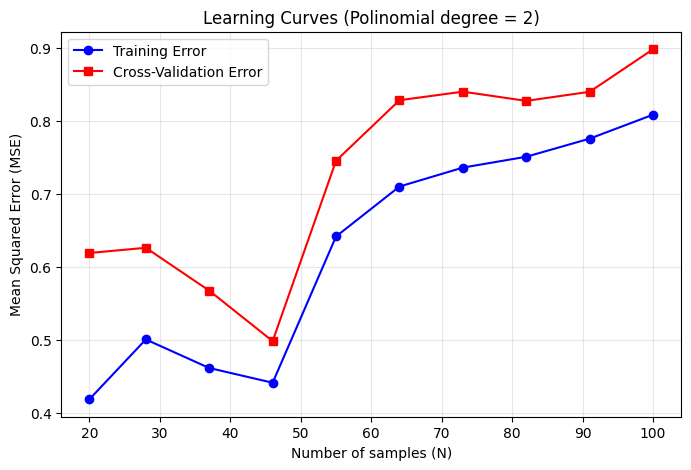

In [11]:

# 1. Determiniamo il grado migliore dalla cella precedente
best_d = degrees[np.argmin(cv_errors)]


# 2. Definiamo i campionamenti (da 20 dati fino al totale)
N_sizes = np.linspace(20, len(z_sample), 10, dtype=int)
lc_train_err = []
lc_cv_err = []

# Setup della Cross-Validation
kf_lc = KFold(n_splits=5, shuffle=True, random_state=42)

for N in N_sizes:
    # Usiamo solo i primi N dati del dataset (già mischiato o casuale)
    z_sub = z_sample[:N]
    mu_sub = mu_sample[:N]
    dmu_sub = dmu[:N]
    # Se hai errori sulle y, ricordati di fare lo slicing anche di sigma_mu[:N]
    
    t_err_fold = []
    v_err_fold = []
    
    
    X_resh = z_sub[:, np.newaxis]
    for train_idx, val_idx in kf_lc.split(X_resh):
        X_train, X_val = X_resh[train_idx], X_resh[val_idx]
        y_train, y_val = mu_sub[train_idx], mu_sub[val_idx]
        err_train, err_val = dmu_sub[train_idx], dmu_sub[val_idx]
        # Fit del modello
        model = PolynomialRegression(best_d)
        model.fit(X_train, y_train, err_train)
        
        # Calcolo errore (MSE)
        t_err_fold.append(mean_squared_error(y_train, model.predict(X_train)))
        v_err_fold.append(mean_squared_error(y_val, model.predict(X_val)))
    
    # Salviamo la media degli errori per questa dimensione N
    lc_train_err.append(np.mean(t_err_fold))
    lc_cv_err.append(np.mean(v_err_fold))

# 3. Plot delle Learning Curves
plt.figure(figsize=(8, 5))
plt.plot(N_sizes, lc_train_err, 'o-', label='Training Error', color='blue')
plt.plot(N_sizes, lc_cv_err, 's-', label='Cross-Validation Error', color='red')
plt.xlabel('Number of samples (N)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Learning Curves (Polinomial degree = {best_d})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Not that good :(

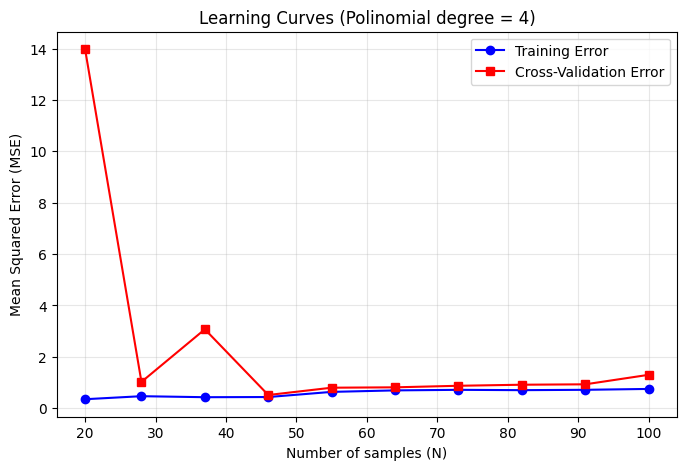

In [12]:

# 1. Determiniamo il grado migliore dalla cella precedente
best_d = 4#degrees[np.argmin(cv_errors)]


# 2. Definiamo i campionamenti (da 20 dati fino al totale)
N_sizes = np.linspace(20, len(z_sample), 10, dtype=int)
lc_train_err = []
lc_cv_err = []

# Setup della Cross-Validation
kf_lc = KFold(n_splits=5, shuffle=True, random_state=42)

for N in N_sizes:
    # Usiamo solo i primi N dati del dataset (già mischiato o casuale)
    z_sub = z_sample[:N]
    mu_sub = mu_sample[:N]
    # Se hai errori sulle y, ricordati di fare lo slicing anche di sigma_mu[:N]
    dmu_sub = dmu[:N]
    # Se hai errori sulle y, ricordati di fare lo slicing anche di sigma_mu[:N]
    
    t_err_fold = []
    v_err_fold = []
    
    
    X_resh = z_sub[:, np.newaxis]
    for train_idx, val_idx in kf_lc.split(X_resh):
        X_train, X_val = X_resh[train_idx], X_resh[val_idx]
        y_train, y_val = mu_sub[train_idx], mu_sub[val_idx]
        err_train, err_val = dmu_sub[train_idx], dmu_sub[val_idx]
        # Fit del modello
        model = PolynomialRegression(best_d)
        model.fit(X_train, y_train, err_train) 
    
        # Calcolo errore (MSE)
        t_err_fold.append(mean_squared_error(y_train, model.predict(X_train)))
        v_err_fold.append(mean_squared_error(y_val, model.predict(X_val)))
    
    # Salviamo la media degli errori per questa dimensione N
    lc_train_err.append(np.mean(t_err_fold))
    lc_cv_err.append(np.mean(v_err_fold))

# 3. Plot delle Learning Curves
plt.figure(figsize=(8, 5))
plt.plot(N_sizes, lc_train_err, 'o-', label='Training Error', color='blue')
plt.plot(N_sizes, lc_cv_err, 's-', label='Cross-Validation Error', color='red')
plt.xlabel('Number of samples (N)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Learning Curves (Polinomial degree = {best_d})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Polyfit

Text(0.5, 1.0, 'Validation curve')

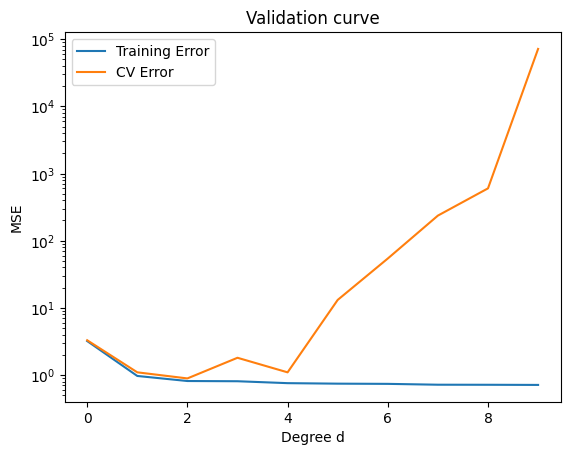

In [14]:
degrees = np.arange(0, 10)
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_errors = []
cv_errors = []

for d in degrees:
    t_err = []
    v_err = []
    
    
    
    
    for train_idx, val_idx in kf.split(z_reshape):
        # Split
        X_train, X_val = z_sample[train_idx], z_sample[val_idx]
        y_train, y_val = mu_sample[train_idx], mu_sample[val_idx]
        err_train, err_val = dmu[train_idx], dmu[val_idx]
        p = np.polyfit(X_train, y_train, deg=d, w= 1/err_train)
        
        
        # Predict
        t_err.append(mean_squared_error(y_train, np.polyval(p, X_train)))
        v_err.append(mean_squared_error(y_val,np.polyval(p, X_val)))
        
    train_errors.append(np.mean(t_err))
    cv_errors.append(np.mean(v_err))

# Plot Validation Curve
plt.plot(degrees, (train_errors), label='Training Error')
plt.plot(degrees, cv_errors, label='CV Error')
plt.yscale('log')
plt.xlabel('Degree d')
plt.ylabel('MSE')
plt.legend()
plt.title("Validation curve")

In [15]:

# 1. Determiniamo il grado migliore dalla cella precedente
best_d_poly = degrees[np.argmin(cv_errors)]


### Basis function

(25.0, 50.0)

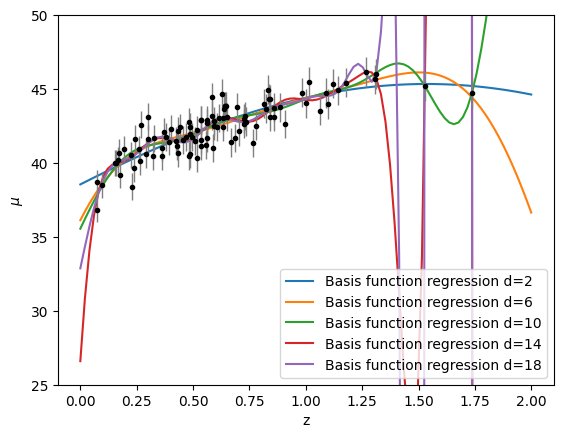

In [19]:
from astroML.linear_model import BasisFunctionRegression, NadarayaWatson
z= np.linspace(0,2,100)
for n in np.arange(1,20)[1::4]:

    mu_basis = np.linspace(0,2,n)[:, None]
    sigma_basis = (mu_basis[1] - mu_basis[0])

    model = BasisFunctionRegression('gaussian', mu=mu_basis, sigma=sigma_basis)
    model.fit(z_sample[:,np.newaxis], mu_sample, dmu)
    
   
    mu_fit = model.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label='Basis function regression d='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(25,50)

Text(0.5, 1.0, 'Validation curve: Basis Function')

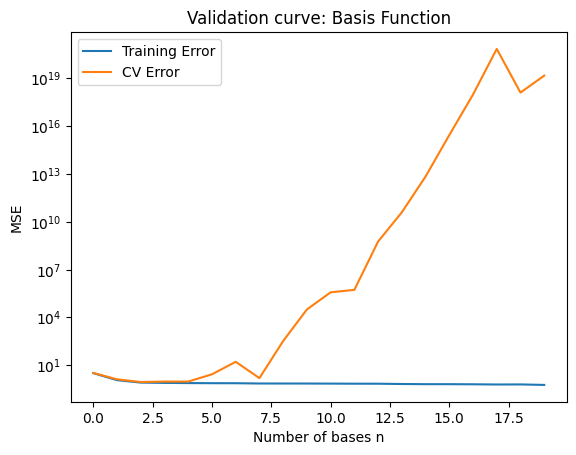

In [21]:
n_range = np.arange(0, 20) # from 0 to 20 basis
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_errors_basis = []
cv_errors_basis = []

for n in n_range:
    t_err = []
    v_err = []
    
    mu_basis = np.linspace(0, 2, n)[:, None]
    sigma_basis = (mu_basis[1] - mu_basis[0]) if n > 1 else 1.0

    for train_idx, val_idx in kf.split(z_sample):
        # Split
        X_train, X_val = z_sample[train_idx], z_sample[val_idx]
        y_train, y_val = mu_sample[train_idx], mu_sample[val_idx]
        err_train = dmu[train_idx]
        
        # Fit
        model = BasisFunctionRegression('gaussian', mu=mu_basis, sigma=sigma_basis)
        model.fit(X_train[:, np.newaxis], y_train, err_train)
        
        # Predict and error
        t_err.append(mean_squared_error(y_train, model.predict(X_train[:, np.newaxis])))
        v_err.append(mean_squared_error(y_val, model.predict(X_val[:, np.newaxis])))
        
    train_errors_basis.append(np.mean(t_err))
    cv_errors_basis.append(np.mean(v_err))

# Plot Validation Curve
plt.plot(n_range, train_errors_basis, label='Training Error')
plt.plot(n_range, cv_errors_basis, label='CV Error')
plt.yscale('log')
plt.xlabel('Number of bases n')
plt.ylabel('MSE')
plt.legend()
plt.title("Validation curve: Basis Function")

In [22]:
best_n_bf = n_range[np.argmin(cv_errors_basis)]

In [23]:
best_n_bf

np.int64(2)

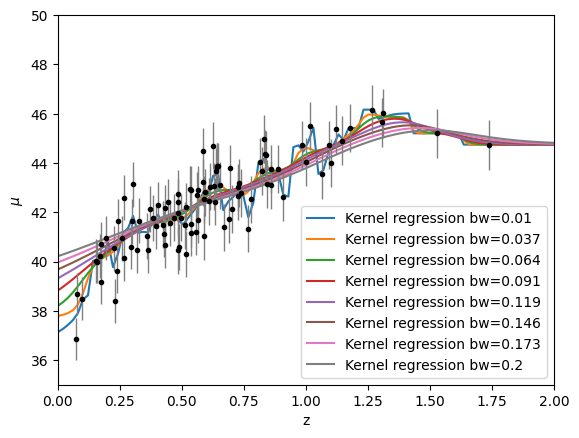

In [24]:
for bw in np.round(np.linspace(0.01,0.2,8),3):

    regressor = NadarayaWatson('gaussian', bw)

    regressor.fit(z_sample[:,np.newaxis], mu_sample) 
    mu_fit = regressor.predict(z[:,np.newaxis])
   
    mu_fit = regressor.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label='Kernel regression bw='+str(bw))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

Text(0.5, 1.0, 'Validation curve: Nadaraya-Watson')

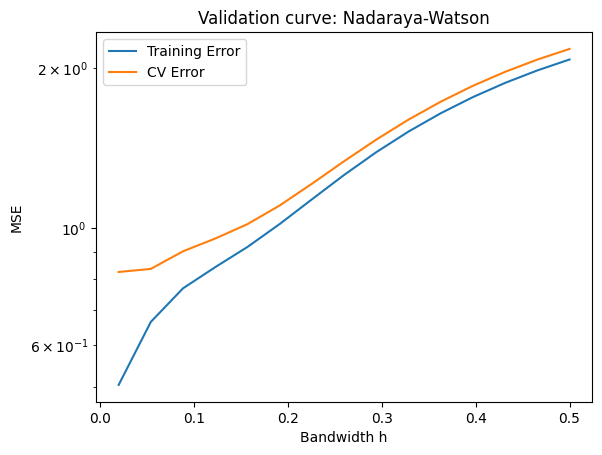

In [28]:

h_range = np.linspace(0.02, 0.5, 15)# kernel width
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_errors_kernel = []
cv_errors_kernel = []
for h in h_range:
    t_err = []
    v_err = []
    
    for train_idx, val_idx in kf.split(z_sample):
        # Split
        X_train, X_val = z_sample[train_idx], z_sample[val_idx]
        y_train, y_val = mu_sample[train_idx], mu_sample[val_idx]
        err_train = dmu[train_idx]
        
        # Fit
        model = NadarayaWatson('gaussian', h=h)
        model.fit(X_train[:, np.newaxis], y_train, err_train)
        
        # Predict & Error
        t_err.append(mean_squared_error(y_train, model.predict(X_train[:, np.newaxis])))
        v_err.append(mean_squared_error(y_val, model.predict(X_val[:, np.newaxis])))
        
    train_errors_kernel.append(np.mean(t_err))
    cv_errors_kernel.append(np.mean(v_err))
# Plot Validation Curve
plt.plot(h_range, train_errors_kernel, label='Training Error')
plt.plot(h_range, cv_errors_kernel, label='CV Error')
plt.yscale('log')
plt.xlabel('Bandwidth h')
plt.ylabel('MSE')
plt.legend()
plt.title("Validation curve: Nadaraya-Watson")

In [29]:
best_bw = h_range[np.argmin(cv_errors_kernel)]

## Theory vs prediction

In [36]:
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0, 2, 200)
mu_lcdm = cosmo.distmod(z)

C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\astropy\cosmology\_src\flrw\base.py:1182: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


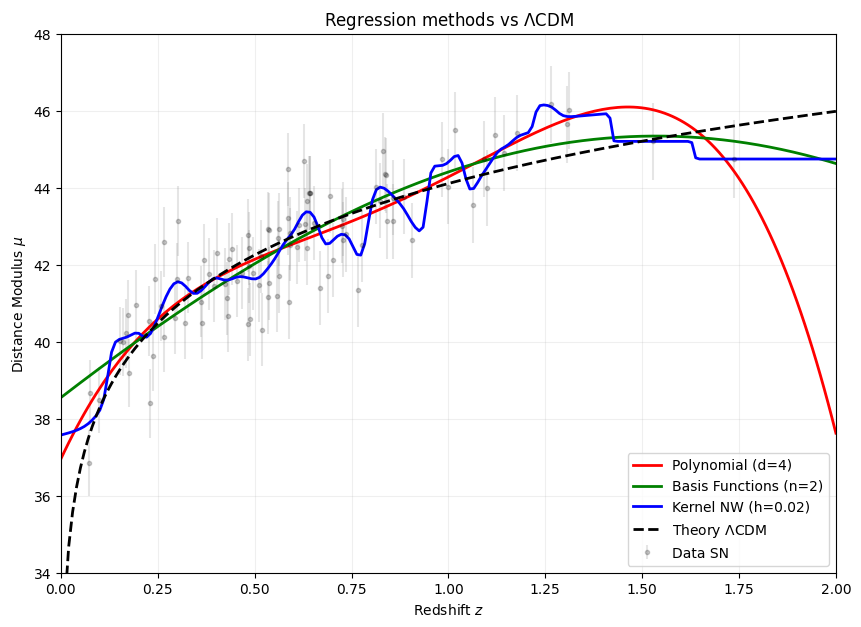

In [38]:

best_poly = PolynomialRegression(degree=best_d)
best_poly.fit(z_sample[:, np.newaxis], mu_sample, dmu)

mu_basis_opt = np.linspace(0, 2, best_n_bf)[:, None]
sigma_basis_opt = (mu_basis_opt[1] - mu_basis_opt[0])
best_basis = BasisFunctionRegression('gaussian', mu=mu_basis_opt, sigma=sigma_basis_opt)
best_basis.fit(z_sample[:, np.newaxis], mu_sample, dmu)

# Kernel Regression (NW)
# Nota: h deve essere abbastanza grande da evitare i NaN (es. > 0.05)
best_kernel = NadarayaWatson('gaussian', h=best_bw)
best_kernel.fit(z_sample[:, np.newaxis], mu_sample, dmu)

# 3. Predizioni sul range z_range
z_plot = np.linspace(0, 2, 200)[:, np.newaxis]
mu_poly_pred = best_poly.predict(z_plot)
mu_basis_pred = best_basis.predict(z_plot)
mu_kernel_pred = best_kernel.predict(z_plot)

# 4. Plot finale di confronto
plt.figure(figsize=(10, 7))

# Dati sperimentali
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', ecolor='gray', alpha=0.2, label='Data SN')

# Modelli statistici (Data-driven)
plt.plot(z_plot, mu_poly_pred, 'r-', lw=2, label=f'Polynomial (d={best_d})')
plt.plot(z_plot, mu_basis_pred, 'g-', lw=2, label=f'Basis Functions (n={best_n_bf})')
plt.plot(z_plot, mu_kernel_pred, 'b-', lw=2, label=f'Kernel NW (h={best_bw:.2f})')

# Modello Teorico (Fisica)
plt.plot(z, mu_lcdm, 'k--', lw=2, label=r'Theory $\Lambda$CDM')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance Modulus $\mu$')
plt.title(r'Regression methods vs $\Lambda$CDM')
plt.legend(loc='lower right')
plt.ylim(34, 48)
plt.xlim(0, 2)
plt.grid(alpha=0.2)
plt.show()